# SISO Convolution — Toeplitz + Diagonal (Halevi-Shoup) Metodu / OpenFHE

Bir convolution katmanini Toeplitz matrisine cevirip diagonal metotla sifreli olarak hesapliyorum. Toeplitz matrisini input boyutu, kernel, stride, padding ve dilation'a gore kuruyorum (tek ornege sabit degil). Once kurucuyu iki bagimsiz plaintext referansla dogruluyorum, sonra kucuk bir ornek, gercek MNIST (same ve strided) ve farkli parametrelerle test ediyorum. Sonuclari sifresiz NumPy/TensorFlow ile karsilastiriyorum.

## Kurulum

OpenFHE icin Python 3.10 ortamini kuruyorum.

In [1]:
# ortami kuruyorum (python 3.10 + openfhe)
!pip install -q uv
!uv python install 3.10
!uv venv /content/fhe310 --python 3.10
!uv pip install --python /content/fhe310/bin/python "openfhe==1.5.1.0.22.4" numpy scipy
!/content/fhe310/bin/python -c "import openfhe, sys; print('OpenFHE hazir, Python', sys.version.split()[0])"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 48.1 MB/s eta 0:00:00
Installed Python 3.10.20 in 1.48s
 + cpython-3.10.20-linux-x86_64-gnu (python3.10)
Using CPython 3.10.20
Creating virtual environment at: fhe310
Activate with: source fhe310/bin/activate
Using Python 3.10.20 environment at: fhe310
Resolved 3 packages in 300ms
Prepared 3 packages in 1.70s
Installed 3 packages in 39ms
 + numpy==2.2.6
 + openfhe==1.5.1.0.22.4
 + scipy==1.15.3
OpenFHE hazir, Python 3.10.20


## Yontem

Convolution'i y = T x seklinde yaziyorum; T'nin her satiri bir cikti pikseline karsilik gelir. T genelde dikdortgen oldugu icin S x S (S = 2'nin kuvveti) bir kareye sifirla gomuyorum, sonra sadece sifir olmayan diagonalleri isliyorum. Boylece rotation ve carpim sayisi sifir olmayan diagonal sayisina esit oluyor. Kurucunun dogrulugunu iki bagimsiz plaintext referansla (elle yazilmis sliding-window ve SciPy correlate2d) ayrica FHE'siz olarak kontrol ediyorum.

In [2]:
%%writefile /content/siso_fhe.py
import argparse
import json
import os
import time
import numpy as np
from scipy.signal import correlate2d
from openfhe import CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE

OUT = "/content"
os.makedirs(OUT, exist_ok=True)


def _pair(v):
    return (v, v) if isinstance(v, int) else v


def build_toeplitz(H_in, W_in, kernel, stride=1, padding=0, dilation=1):
    sH, sW = _pair(stride)
    pH, pW = _pair(padding)
    dH, dW = _pair(dilation)
    kH, kW = kernel.shape
    H_pad, W_pad = H_in + 2 * pH, W_in + 2 * pW
    eff_kH = (kH - 1) * dH + 1
    eff_kW = (kW - 1) * dW + 1
    H_out = (H_pad - eff_kH) // sH + 1
    W_out = (W_pad - eff_kW) // sW + 1
    if H_out <= 0 or W_out <= 0:
        raise ValueError("gecersiz stride/padding/dilation/kernel bilesimi")
    padded_idx = -np.ones((H_pad, W_pad), dtype=int)
    padded_idx[pH:pH + H_in, pW:pW + W_in] = np.arange(H_in * W_in).reshape(H_in, W_in)
    T = np.zeros((H_out * W_out, H_in * W_in))
    for oh in range(H_out):
        for ow in range(W_out):
            row = oh * W_out + ow
            for kh in range(kH):
                for kw in range(kW):
                    src = padded_idx[oh * sH + kh * dH, ow * sW + kw * dW]
                    if src >= 0:
                        T[row, src] += kernel[kh, kw]
    return T, (H_out, W_out)


def manual_conv2d(x, kernel, stride=1, padding=0, dilation=1):
    sH, sW = _pair(stride); pH, pW = _pair(padding); dH, dW = _pair(dilation)
    kH, kW = kernel.shape
    xp = np.pad(x, ((pH, pH), (pW, pW)))
    Hp, Wp = xp.shape
    eff_kH = (kH - 1) * dH + 1
    eff_kW = (kW - 1) * dW + 1
    H_out = (Hp - eff_kH) // sH + 1
    W_out = (Wp - eff_kW) // sW + 1
    out = np.zeros((H_out, W_out))
    for oh in range(H_out):
        for ow in range(W_out):
            acc = 0.0
            for kh in range(kH):
                for kw in range(kW):
                    acc += xp[oh * sH + kh * dH, ow * sW + kw * dW] * kernel[kh, kw]
            out[oh, ow] = acc
    return out


def scipy_conv2d(x, kernel, stride=1, padding=0):
    sH, sW = _pair(stride); pH, pW = _pair(padding)
    xp = np.pad(x, ((pH, pH), (pW, pW)))
    full = correlate2d(xp, kernel, mode="valid")
    return full[::sH, ::sW]


def next_pow2(n):
    p = 1
    while p < n:
        p *= 2
    return p


def nonzero_diagonals(T, S):
    R, C = T.shape
    M = np.zeros((S, S))
    M[:R, :C] = T
    base = np.arange(S)
    diags = {}
    for k in range(S):
        d = M[base, (base + k) % S]
        if np.any(d != 0):
            diags[k] = d
    return diags


def build_cc(S, depth=1, scale=50):
    p = CCParamsCKKSRNS()
    p.SetMultiplicativeDepth(depth)
    p.SetScalingModSize(scale)
    p.SetBatchSize(S)
    cc = GenCryptoContext(p)
    cc.Enable(PKE); cc.Enable(KEYSWITCH); cc.Enable(LEVELEDSHE)
    return cc


def he_matvec(cc, keys, x_vec, diag_pts, S, repeats=5):
    times = []
    ct_final = None
    for _ in range(max(1, repeats)):
        xp = np.zeros(S); xp[:len(x_vec)] = x_vec
        ct_x = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(list(xp)))
        t0 = time.perf_counter()
        ct_acc = None
        for k, pt in diag_pts.items():
            ct_rot = ct_x if k == 0 else cc.EvalRotate(ct_x, k)
            part = cc.EvalMult(ct_rot, pt)
            ct_acc = part if ct_acc is None else cc.EvalAdd(ct_acc, part)
        times.append(time.perf_counter() - t0)
        ct_final = ct_acc
    return ct_final, float(np.mean(times)), float(np.std(times))


def run_experiment(name, image, kernel, stride, padding, dilation=1, atol=1e-2, repeats=5, save_prefix=None):
    H_in, W_in = image.shape
    T, (H_out, W_out) = build_toeplitz(H_in, W_in, kernel, stride, padding, dilation)
    expected = (T @ image.flatten()).reshape(H_out, W_out)
    S = next_pow2(max(T.shape))
    diags = nonzero_diagonals(T, S)
    rot_idx = sorted(k for k in diags if k != 0)
    cc = build_cc(S)
    keys = cc.KeyGen()
    cc.EvalMultKeyGen(keys.secretKey)
    if rot_idx:
        cc.EvalRotateKeyGen(keys.secretKey, rot_idx)
    diag_pts = {k: cc.MakeCKKSPackedPlaintext(list(d)) for k, d in diags.items()}
    ct_out, t_mean, t_std = he_matvec(cc, keys, image.flatten(), diag_pts, S, repeats)
    pt = cc.Decrypt(ct_out, keys.secretKey)
    pt.SetLength(H_out * W_out)
    decrypted = np.array(pt.GetRealPackedValue()).reshape(H_out, W_out)
    match = bool(np.allclose(decrypted, expected, atol=atol))
    mae = float(np.abs(decrypted - expected).mean())
    r = dict(name=name, input_shape=[H_in, W_in], toeplitz_shape=list(T.shape),
             output_shape=[H_out, W_out], slots=S, nonzero_diagonals=len(diags),
             rotations=len(rot_idx), plaintext_mults=len(diags),
             time_mean_s=t_mean, time_std_s=t_std, repeats=repeats, match=match, mean_abs_error=mae)
    if save_prefix:
        np.save(f"{OUT}/{save_prefix}_input.npy", image)
        np.save(f"{OUT}/{save_prefix}_kernel.npy", kernel)
        np.save(f"{OUT}/{save_prefix}_expected.npy", expected)
        np.save(f"{OUT}/{save_prefix}_decrypted.npy", decrypted)
    return r


def print_result(r):
    print("=" * 64)
    print(r["name"])
    print("=" * 64)
    print(f"input={tuple(r['input_shape'])} toeplitz={tuple(r['toeplitz_shape'])} "
          f"output={tuple(r['output_shape'])} slots={r['slots']}")
    print(f"match: {r['match']} | mean abs error: {r['mean_abs_error']:.3e}")
    print(f"non-zero diagonals: {r['nonzero_diagonals']} | rotations: {r['rotations']} "
          f"| plaintext mults: {r['plaintext_mults']}")
    print(f"time: {r['time_mean_s']:.4f} +/- {r['time_std_s']:.4f} s ({r['repeats']} runs)")
    print("=" * 64 + "\n")


def run_sanity():
    rng = np.random.default_rng(0)
    configs = [
        dict(H=6, W=6, k=3, s=1, p=0, d=1),
        dict(H=7, W=5, k=3, s=2, p=1, d=1),
        dict(H=8, W=8, k=2, s=2, p=0, d=1),
        dict(H=10, W=10, k=3, s=1, p=1, d=1),
        dict(H=9, W=7, k=3, s=2, p=1, d=2),
    ]
    print(f"{'H':>3}{'W':>3}{'k':>3}{'s':>3}{'p':>3}{'d':>3}   out     T=manual  T=scipy  manual=scipy")
    ok_all = True
    for c in configs:
        x = rng.uniform(-3, 3, size=(c["H"], c["W"]))
        ker = rng.uniform(-1, 1, size=(c["k"], c["k"]))
        T, (Ho, Wo) = build_toeplitz(c["H"], c["W"], ker, c["s"], c["p"], c["d"])
        viaT = (T @ x.flatten()).reshape(Ho, Wo)
        m = np.allclose(viaT, manual_conv2d(x, ker, c["s"], c["p"], c["d"]), atol=1e-8)
        if c["d"] == 1:
            sc = np.allclose(viaT, scipy_conv2d(x, ker, c["s"], c["p"]), atol=1e-8)
            cr = np.allclose(manual_conv2d(x, ker, c["s"], c["p"]), scipy_conv2d(x, ker, c["s"], c["p"]), atol=1e-8)
        else:
            sc, cr = "n/a", "n/a"
        ok_all = ok_all and m and (sc in (True, "n/a"))
        print(f"{c['H']:>3}{c['W']:>3}{c['k']:>3}{c['s']:>3}{c['p']:>3}{c['d']:>3}   "
              f"{str((Ho,Wo)):>7}  {str(m):>8}  {str(sc):>7}  {str(cr):>12}")
    print(f"\n[{'OK' if ok_all else 'FAIL'}] Toeplitz kurucusu iki bagimsiz referansla eslesti.\n")


def _load_mnist():
    if os.path.exists(f"{OUT}/mnist_sample.npy"):
        img = np.load(f"{OUT}/mnist_sample.npy").astype(float)
        src = "gercek MNIST"
    else:
        yy, xx = np.mgrid[0:28, 0:28]
        img = (128 + 100 * np.sin(xx / 3.0) * np.cos(yy / 4.0)).clip(0, 255)
        src = "sentetik 28x28"
    return img / 255.0, src


def run_small():
    rng = np.random.default_rng(42)
    x = rng.uniform(-3, 3, size=(6, 6))
    k = rng.uniform(-1, 1, size=(3, 3))
    print_result(run_experiment("Kucuk ornek (6x6, k=3, s=1, p=0)", x, k, 1, 0, repeats=5, save_prefix="small"))


def run_mnist_same():
    img, src = _load_mnist()
    print(f"[girdi: {src}]")
    blur = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=float) / 16.0
    print_result(run_experiment("MNIST 28x28 same conv (blur, s=1, p=1)", img, blur, 1, 1, repeats=5, save_prefix="mnist_same"))


def run_mnist_strided():
    img, src = _load_mnist()
    print(f"[girdi: {src}]")
    edge = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float)
    print_result(run_experiment("MNIST 28x28 strided conv (edge, s=2, p=1)", img, edge, 2, 1, atol=5e-2, repeats=3, save_prefix="mnist_strided"))


def run_sweep():
    rng = np.random.default_rng(7)
    x = rng.integers(0, 9, size=(8, 8)).astype(float)
    k3 = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=float)
    k2 = np.array([[1, 1], [1, 1]], dtype=float)
    cases = [
        ("8x8 same (3x3, s=1, p=1)", k3, 1, 1),
        ("8x8 valid (3x3, s=1, p=0)", k3, 1, 0),
        ("8x8 strided (3x3, s=2, p=1)", k3, 2, 1),
        ("8x8 strided (3x3, s=3, p=1)", k3, 3, 1),
        ("8x8 pool (2x2, s=2, p=0)", k2, 2, 0),
    ]
    print(f"{'config':30s} {'out':>7} {'nz_diag':>8} {'rot':>5} {'pmult':>6} {'time(s)':>9} {'match':>7}")
    print("-" * 78)
    rows = []
    for name, ker, s, p in cases:
        r = run_experiment(name, x, ker, s, p, repeats=3)
        rows.append(r)
        print(f"{name:30s} {str(tuple(r['output_shape'])):>7} {r['nonzero_diagonals']:>8} "
              f"{r['rotations']:>5} {r['plaintext_mults']:>6} {r['time_mean_s']:>9.4f} {str(r['match']):>7}")
    print()
    return rows


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", choices=["sanity", "small", "mnist_same", "mnist_strided", "sweep", "all"], default="all")
    args = ap.parse_args()
    if args.mode in ("sanity", "all"): run_sanity()
    if args.mode in ("small", "all"): run_small()
    if args.mode in ("mnist_same", "all"): run_mnist_same()
    if args.mode in ("mnist_strided", "all"): run_mnist_strided()
    if args.mode in ("sweep", "all"): run_sweep()


Writing /content/siso_fhe.py


## Gercek MNIST rakami

Varsayilan Colab kernel'inden gercek bir MNIST rakami kaydediyorum; bulunamazsa script sentetik 28x28 girdiye duser.

In [3]:
# gercek mnist rakamini kaydediyorum, bulamazsa sentetik kullanilir
try:
    import numpy as np
    from tensorflow.keras.datasets import mnist
    (x_train, _), _ = mnist.load_data()
    np.save("/content/mnist_sample.npy", x_train[7])
    print("mnist kaydedildi:", x_train[7].shape)
except Exception as e:
    print("mnist yuklenemedi, sentetik kullanilacak:", e)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
mnist kaydedildi: (28, 28)


## Dogrulama (FHE'siz)

Toeplitz kurucusunu farkli stride/padding/dilation/kernel kombinasyonlarinda iki bagimsiz referansa karsi dogruluyorum.

In [4]:
# toeplitz kurucusunu iki bagimsiz referansla dogruluyorum
!/content/fhe310/bin/python /content/siso_fhe.py --mode sanity

  H  W  k  s  p  d   out     T=manual  T=scipy  manual=scipy
  6  6  3  1  0  1    (4, 4)      True     True          True
  7  5  3  2  1  1    (4, 3)      True     True          True
  8  8  2  2  0  1    (4, 4)      True     True          True
 10 10  3  1  1  1   (10, 10)      True     True          True
  9  7  3  2  1  2    (4, 3)      True      n/a           n/a

[OK] Toeplitz kurucusu iki bagimsiz referansla eslesti.



## Kucuk ornek

6x6 rastgele girdi, 3x3 rastgele kernel. Sifreli cikti plaintext ile karsilastiriliyor.

In [5]:
# kucuk ornek
!/content/fhe310/bin/python /content/siso_fhe.py --mode small

Kucuk ornek (6x6, k=3, s=1, p=0)
input=(6, 6) toeplitz=(16, 36) output=(4, 4) slots=64
match: True | mean abs error: 2.593e-13
non-zero diagonals: 21 | rotations: 20 | plaintext mults: 21
time: 1.2892 +/- 0.5208 s (5 runs)



## MNIST — same convolution

Gercek 28x28 MNIST rakami, 3x3 Gaussian blur, stride 1 (same). Kolay durum: az sayida diagonal.

In [6]:
# mnist same convolution
!/content/fhe310/bin/python /content/siso_fhe.py --mode mnist_same

[girdi: gercek MNIST]
MNIST 28x28 same conv (blur, s=1, p=1)
input=(28, 28) toeplitz=(784, 784) output=(28, 28) slots=1024
match: True | mean abs error: 5.755e-13
non-zero diagonals: 9 | rotations: 8 | plaintext mults: 9
time: 0.4528 +/- 0.1495 s (5 runs)



## MNIST — strided convolution

Ayni rakam, 3x3 kenar (edge) kernel, stride 2. Daha zorlayici durum: strided oldugu icin diagonal sayisi cok artiyor.

In [7]:
# mnist strided convolution
!/content/fhe310/bin/python /content/siso_fhe.py --mode mnist_strided

[girdi: gercek MNIST]
MNIST 28x28 strided conv (edge, s=2, p=1)
input=(28, 28) toeplitz=(196, 784) output=(14, 14) slots=1024
match: True | mean abs error: 6.260e-12
non-zero diagonals: 576 | rotations: 575 | plaintext mults: 576
time: 14.6999 +/- 0.1041 s (3 runs)



## Farkli parametreler

Ayni kodu 8x8 girdide farkli stride/padding ile deniyorum. Stride arttikca sifir olmayan diagonal sayisi da artiyor.

In [8]:
# farkli stride/padding
!/content/fhe310/bin/python /content/siso_fhe.py --mode sweep

config                             out  nz_diag   rot  pmult   time(s)   match
------------------------------------------------------------------------------
8x8 same (3x3, s=1, p=1)        (8, 8)        6     6      6    0.1271    True
8x8 valid (3x3, s=1, p=0)       (6, 6)       15    14     15    0.3550    True
8x8 strided (3x3, s=2, p=1)     (4, 4)       46    45     46    1.3252    True
8x8 strided (3x3, s=3, p=1)     (3, 3)       24    24     24    0.5504    True
8x8 pool (2x2, s=2, p=0)        (4, 4)       37    36     37    1.1919    True



## Gorseller

Girdi, plaintext ve homomorfik ciktilari (ve farki) yan yana ciziyorum.

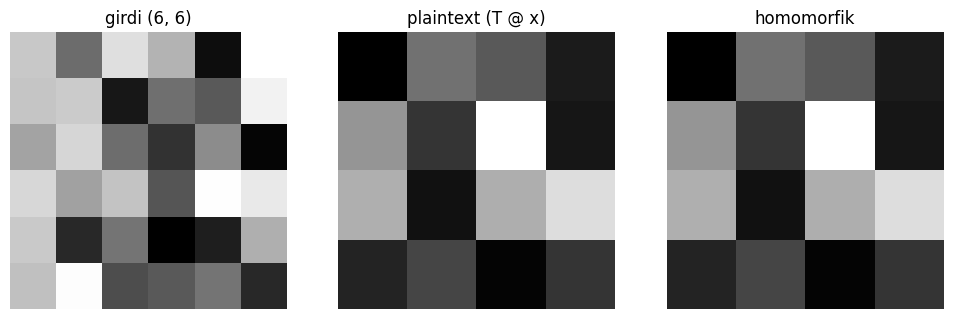

max |fark| = 6.679101716144942e-13


In [9]:
# kucuk ornek gorseli
import numpy as np, matplotlib.pyplot as plt
img=np.load("/content/small_input.npy"); exp=np.load("/content/small_expected.npy"); dec=np.load("/content/small_decrypted.npy")
fig,ax=plt.subplots(1,3,figsize=(10,3.2))
ax[0].imshow(img,cmap="gray"); ax[0].set_title(f"girdi {img.shape}")
ax[1].imshow(exp,cmap="gray"); ax[1].set_title("plaintext (T @ x)")
ax[2].imshow(dec,cmap="gray"); ax[2].set_title("homomorfik")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("max |fark| =", float(np.abs(exp-dec).max()))

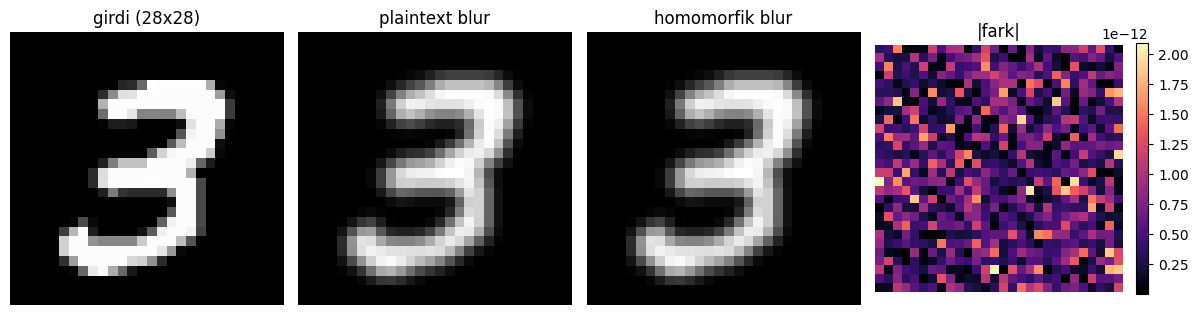

max |fark| = 2.0954199801274817e-12


In [10]:
# mnist same gorseli
import numpy as np, matplotlib.pyplot as plt
img=np.load("/content/mnist_same_input.npy"); exp=np.load("/content/mnist_same_expected.npy"); dec=np.load("/content/mnist_same_decrypted.npy")
fig,ax=plt.subplots(1,4,figsize=(12,3.4))
ax[0].imshow(img,cmap="gray"); ax[0].set_title("girdi (28x28)")
ax[1].imshow(exp,cmap="gray"); ax[1].set_title("plaintext blur")
ax[2].imshow(dec,cmap="gray"); ax[2].set_title("homomorfik blur")
im=ax[3].imshow(np.abs(exp-dec),cmap="magma"); ax[3].set_title("|fark|")
fig.colorbar(im,ax=ax[3],fraction=0.046)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("max |fark| =", float(np.abs(exp-dec).max()))

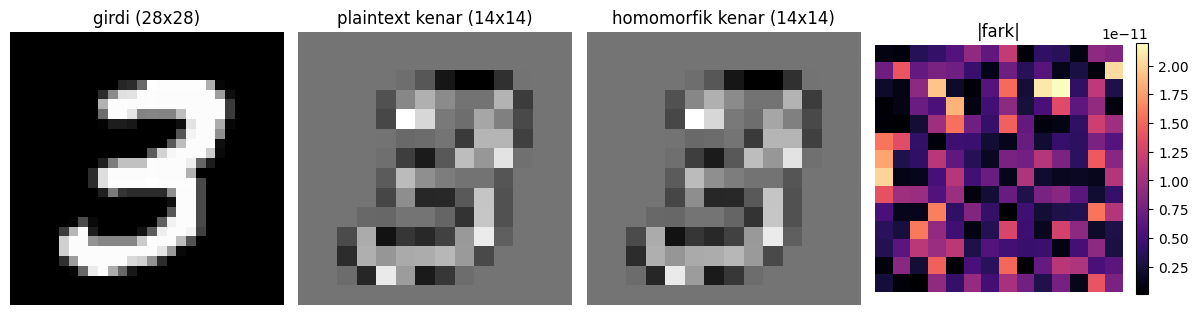

max |fark| = 2.2001733768206577e-11


In [11]:
# mnist strided gorseli
import numpy as np, matplotlib.pyplot as plt
img=np.load("/content/mnist_strided_input.npy"); exp=np.load("/content/mnist_strided_expected.npy"); dec=np.load("/content/mnist_strided_decrypted.npy")
fig,ax=plt.subplots(1,4,figsize=(12,3.4))
ax[0].imshow(img,cmap="gray"); ax[0].set_title("girdi (28x28)")
ax[1].imshow(exp,cmap="gray"); ax[1].set_title("plaintext kenar (14x14)")
ax[2].imshow(dec,cmap="gray"); ax[2].set_title("homomorfik kenar (14x14)")
im=ax[3].imshow(np.abs(exp-dec),cmap="magma"); ax[3].set_title("|fark|")
fig.colorbar(im,ax=ax[3],fraction=0.046)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("max |fark| =", float(np.abs(exp-dec).max()))

## TensorFlow kontrolu

Strided MNIST convolution'ini tf.nn.conv2d ile de hesaplayip NumPy ve homomorfik sonucla ayni mi diye bakiyorum.

In [12]:
# tensorflow ile capraz kontrol (strided mnist)
import numpy as np
try:
    import tensorflow as tf
    img=np.load("/content/mnist_strided_input.npy"); ker=np.load("/content/mnist_strided_kernel.npy")
    ref=np.load("/content/mnist_strided_expected.npy"); he=np.load("/content/mnist_strided_decrypted.npy")
    x_t=tf.constant(img.reshape(1,28,28,1),dtype=tf.float64)
    x_t=tf.pad(x_t,[[0,0],[1,1],[1,1],[0,0]])
    k_t=tf.constant(ker.reshape(3,3,1,1),dtype=tf.float64)
    tf_out=tf.nn.conv2d(x_t,k_t,strides=2,padding="VALID").numpy().reshape(14,14)
    print("TF == NumPy(Toeplitz) :", np.allclose(tf_out,ref,atol=1e-6), "| max fark", f"{np.abs(tf_out-ref).max():.2e}")
    print("TF == homomorfik      :", np.allclose(tf_out,he,atol=1e-3), "| max fark", f"{np.abs(tf_out-he).max():.2e}")
except Exception as e:
    print("tf atlandi:", e)

TF == NumPy(Toeplitz) : True | max fark 8.88e-16
TF == homomorfik      : True | max fark 2.20e-11


## Parametre notu

CKKS ayarlari: tek carpim yaptigim icin multiplicative depth = 1. Olcek (ScalingModSize) 50, bu yaklasik 50-bit hassasiyet veriyor (MAE ~1e-11..1e-13). Slot sayisi S, gomulen kare matrisin boyutunun uzerindeki ilk 2'nin kuvveti; OpenFHE ring boyutunu 128-bit guvenlik icin kendisi seciyor.

## Ozet

Homomorfik Toeplitz matris-vektor carpimi butun deneylerde plaintext sonucla (NumPy sliding-window, SciPy correlate2d ve TensorFlow uc bagimsiz referansla) CKKS gurultu seviyesinde eslesti. Same convolution'da sifir olmayan diagonal sayisi gorüntü boyutundan bagimsiz ve kucuk; strided/valid convolution'da artiyor.